# Определение метрик качества модели

In [1]:
import os
import sys
from pathlib import Path

project_root = Path.cwd().parent
os.chdir(project_root)
sys.path.insert(0, str(project_root))
(project_root / "logs").mkdir(exist_ok=True)

In [2]:
import pandas as pd
from pathlib import Path
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

In [3]:
from scripts.run_pipeline import run_pipeline

### Запуск пайплайна

In [5]:
!python -m scripts.run_pipeline --input_dir data/raw \
--output_dir test_output \
--prefix test \
--yolo-conf 0.05 \
--ocr-conf 0.9 \
--conf 0.09 \
--confidence-level-threshold 0.75 \
--limit 250

🚀 SEFER VISION PIPELINE
📂 Входная папка     : data/raw
📁 Выходная папка    : test_output
🏷️  Префикс          : test
🎯 YOLO conf         : 0.05
✅ CONF_THRESHOLD    : 0.09
🔤 OCR accept conf   : 0.9
📊 Confidence level  : 0.75
⛔ Лимит файлов      : 250
-----------------------------------------------------------------------------------------------

📊 ИТОГОВЫЙ ОТЧЁТ
Файлов обработано     : 250
Успешно               : 204 (81.6%)
С сомнением           : 21
Не распознано         : 25
Отчёт: test_output\sefer_report.csv



Обработка фотографий: 100%|██████████| 250/250 [11:19<00:00,  2.72s/фото]


^C


In [6]:
df = pd.read_csv('test_output\sefer_report.csv')
df.head()

,Имя_файла,Путь_к_оригиналу,Уверенность_детекции,crop_path,Распознанный_текст,Уверенность_OCR,Чистый_номер,Новое_имя_файла,Путь_к_финальному_файлу,Статус,Сообщение,Общий_уровень_уверенности
0,MDZ121_2.JPG,data\raw\MDZ121_2.JPG,0.965241,NaN,121.0,0.973231,121.0,test0121.jpg,test_output\success\test0121.jpg,success,| Детекция: 0.965 | OCR: 0.973,0.94
1,MDZ091 _7.JPG,data\raw\MDZ091 _7.JPG,0.835147,NaN,1.0,0.947462,1.0,test0001.jpg,test_output\success\test0001.jpg,success,| Детекция: 0.835 | OCR: 0.947,0.79
2,SDB284_1.JPG,data\raw\SDB284_1.JPG,0.972507,NaN,284.0,0.978241,284.0,test0284.jpg,test_output\success\test0284.jpg,success,| Детекция: 0.973 | OCR: 0.978,0.95
3,SDB2004.JPG,data\raw\SDB2004.JPG,0.961710,NaN,2004.0,0.977441,2004.0,test2004.jpg,test_output\success\test2004.jpg,success,| Детекция: 0.962 | OCR: 0.977,0.94
4,SDB1009_1.JPG,data\raw\SDB1009_1.JPG,0.959674,NaN,109.0,0.980616,109.0,test0109.jpg,test_output\success\test0109.jpg,success,| Детекция: 0.960 | OCR: 0.981,0.94


In [7]:
df_work = df.copy()

In [8]:
df_work['real_number'] = df_work['Имя_файла'].str.extract(r'^[A-Za-z]+\s*(\d+)')[0].str.zfill(4)
df_work['assigned_number'] = df_work['Новое_имя_файла'].str.extract(r'^[A-Za-z]+\s*(\d+)')[0]

In [9]:
df_metr = df_work[['Имя_файла', 'Общий_уровень_уверенности', 'real_number', 'assigned_number']]
df_metr['assigned_number'] = df_metr['assigned_number'].fillna('не_распознано')
df_metr

,Имя_файла,Общий_уровень_уверенности,real_number,assigned_number
0,MDZ121_2.JPG,0.94,0121,0121
1,MDZ091 _7.JPG,0.79,0091,0001
2,SDB284_1.JPG,0.95,0284,0284
3,SDB2004.JPG,0.94,2004,2004
4,SDB1009_1.JPG,0.94,1009,0109
...,...,...,...,...
245,TUL883_1.JPG,0.97,0883,0883
246,SDB2006.JPG,0.94,2006,2006
247,TUL893_11.JPG,0.78,0893,0893
248,MDZ095 _3.JPG,0.00,0095,не_распознано


## Accuracy

In [10]:
y_true = df_metr['real_number']
y_pred = df_metr['assigned_number']
accuracy = accuracy_score(y_true, y_pred)

In [11]:
print(f"Accuracy = {accuracy:.02f}")

Accuracy = 0.79


## ROC_AUC

Разметка правильности:
       Имя_файла  correct  Общий_уровень_уверенности
0   MDZ121_2.JPG        1                       0.94
1  MDZ091 _7.JPG        0                       0.79
2   SDB284_1.JPG        1                       0.95

ROC-AUC: 0.8058


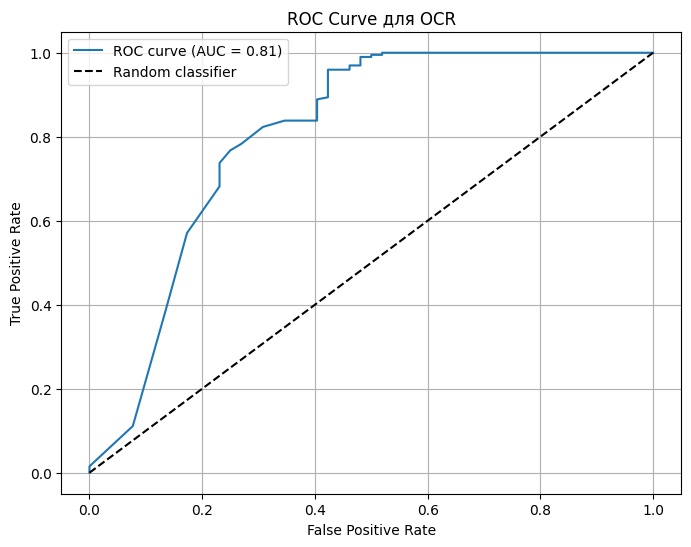

In [12]:
# 1. Создаем бинарные метки (1 - правильно, 0 - ошибка/не распознано)
df_metr['correct'] = (df_metr['real_number'] == df_metr['assigned_number']).astype(int)

print("Разметка правильности:")
print(df_metr[['Имя_файла', 'correct', 'Общий_уровень_уверенности']].head(3))

# 2. Проверяем, есть ли оба класса (иначе roc_auc не посчитать)
if df_metr['correct'].nunique() > 1:
    auc = roc_auc_score(df_metr['correct'], df_metr['Общий_уровень_уверенности'])
    print(f"\nROC-AUC: {auc:.4f}")
else:
    print("\nНевозможно посчитать ROC-AUC: только один класс в выборке")

# 3. Построение ROC-кривой
fpr, tpr, thresholds = roc_curve(df_metr['correct'], df_metr['Общий_уровень_уверенности'])

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve для OCR')
plt.legend()
plt.grid()
plt.show()